## Overview 
In this lab, you'll automate EngageMetrics' weekly employee performance reporting process. Building on your previous analysis, you'll create a Python-based system that transforms employee data into actionable insights for HR leaders. The automated report will track satisfaction trends across work modes (Remote, Hybrid, On-site), monitor department-level metrics, and identify areas for workplace improvement - all while reducing the time spent on manual report generation.

If you get stuck or need a refresher, refer back to the screencast where we demonstrated these concepts step-by-step. The video shows similar examples that can help guide you through this activity.

## Learning Outcomes 
By the end of this lab, you will be able to:
- Create automated data cleaning workflows using Python
- Generate professional visualizations with dynamic data updates
- Combine markdown and code cells for clear report documentation
- Build a reusable reporting template for weekly updates

## Dataset Information 
We'll work with the <b>employee_insights dataset,</b> containing employee performance metrics including:
- Employee demographics and work experience
- Performance scores and project completion rates
- Work modes (Remote, Hybrid, On-site) and satisfaction levels

## Activities

### Activity 1: Data Preparation and Cleaning
Create a reusable data cleaning workflow.

<b>Step 1:</b> Import libraries:

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path
from IPython.display import display, Markdown

<b>Step 2:</b> Adjust paths:

In [48]:
BASE_DIR = Path.cwd().resolve().parent
DATA_DIR = BASE_DIR / "data"
employee_insights_path = DATA_DIR / "employee_insights.csv"

<b>Step 3:</b> load data:

In [49]:
# Load the dataset
df = pd.read_csv(employee_insights_path)

display(df.head())

display(df.info())

,employee_id,age,salary,promotion_eligible,last_training_date,department,work_experience,projects_completed,hours_worked_weekly,work_mode,last_promotion_date,satisfaction_score,overtime_hours
0,E0001,54.0,NaN,NaN,15/08/2023,HR,NaN,14.0,NaN,remote work,2022-05-10,NaN,8.4
1,E0002,NaN,$64761,N,15/08/2023,NaN,1 years,NaN,53.3,HYBRID,05-10-2022,NaN,8.1
2,E0003,54.0,NaN,N,15/08/2023,Marketing,8,6.0,32.6,Hybrid,10/05/2022,10.0,5.2
3,E0004,NaN,NaN,No,NaN,NaN,16,1.0,37.8,Remote,05-10-2022,5.0,NaN
4,E0005,29.0,$61486,Y,15/08/2023,NaN,NaN,1.0,53.3,Hybrid,2022-05-10,NaN,0.3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employee_id          100 non-null    object 
 1   age                  44 non-null     float64
 2   salary               63 non-null     object 
 3   promotion_eligible   84 non-null     object 
 4   last_training_date   71 non-null     object 
 5   department           85 non-null     object 
 6   work_experience      71 non-null     object 
 7   projects_completed   48 non-null     float64
 8   hours_worked_weekly  67 non-null     float64
 9   work_mode            84 non-null     object 
 10  last_promotion_date  74 non-null     object 
 11  satisfaction_score   61 non-null     float64
 12  overtime_hours       70 non-null     float64
dtypes: float64(5), object(8)
memory usage: 10.3+ KB


None

<b>Step 4:</b> Create a function that:
- Handles missing values
- Standardizes the work_mode and department categories
- Converts data types appropriately

In [50]:
def standardize_category(df: pd.DataFrame, category: str, values_map: dict[str, str] | None=None) -> pd.DataFrame:
    df_std = df
    df_std[category] = df_std[category].str.strip().str.lower()
    if values_map is not None:
        df_std[category] = df_std[category].map(values_map)
    return df_std


def clean_salary(df: pd.DataFrame) -> pd.DataFrame:
    df_salary = df
    df_salary['salary'] = df_salary['salary'].str.replace('$', '').replace(',', '').str.strip()
    df_salary['salary'] = pd.to_numeric(df_salary['salary'])
    
    return df_salary


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    df_clean = df.copy()
    
    work_mode_mapping = {
        'remote work': 'remote', 'hybrid': 'hybrid',
        'on-site': 'on-site', 'remote': 'remote'
    }
    
    
    df_clean = standardize_category(df_clean, 'work_mode', values_map=work_mode_mapping)
    df_clean = standardize_category(df_clean, 'department')
    df_clean['work_experience'] = df_clean['work_experience'].str.extract(r'(\d+)').astype(float)
    df_clean = clean_salary(df_clean)

    return df_clean


def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    df_missing = df.copy()
    num_cols = df.select_dtypes(include=['number']).columns
    cat_cols = df.select_dtypes(include=['object']).columns
    
    df_missing[num_cols] = df_missing[num_cols].fillna(df_missing[num_cols].median())
    df_missing[cat_cols] = df_missing[cat_cols].fillna(df_missing[cat_cols].mode().iloc[0])
    
    return df_missing

### Activity 2: Visualization Functions

<b>Step 1:</b> Create a function that generates:
- A bar plot of average satisfaction by department
- Include error bars for standard deviation

In [51]:
def satisfaction_bar_plt(df: pd.DataFrame):
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x='department', y='satisfaction_score',
        hue='department', # Required when using `palette`
        data=df, legend=False, capsize=0.2,
        palette='husl', err_kws={'linewidth': 1.5}
    )
    
    plt.title('Average satisfaction Score by department')
    plt.xlabel('Department')
    plt.ylabel('Satisfaction score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<b>Step 2:</b> Build work mode analysis by creating a function that shows:
- Distribution of satisfaction scores by work_mode
- Use appropriate color schemes and labels

In [52]:
def satisfaction_box_plt(df: pd.DataFrame, plt_type: str='box'):
    if plt_type not in ('violin', 'box'):
        raise ValueError('plt can only be box or violin')
        
    plt.figure(figsize=(12, 6))
    if plt_type == 'box':
        sns.boxplot(
            x='work_mode', y='satisfaction_score', data=df,
            hue='work_mode', palette='husl'
        )
    else:
        sns.violinplot(x='work_mode', y='satisfaction_score', data=df, hue='work_mode', palette='husl')
    
    plt.title('Satisfaction Score Distribution by work mode')
    plt.xlabel('Work Mode')
    plt.ylabel('Satisfaction Score')
    plt.tight_layout()
    plt.show()

### Activity 3: Automated Report Generation

<b>Step 1:</b> Write a function that generates a markdown cell with:
- Dynamic date stamps: uses datetime.now() to insert the current date at the time the function is called
- Key metrics summary
- Section headers for visualizations

In [53]:
def generate_report_markdown(df: pd.DataFrame):
    current_date = datetime.now().strftime('%Y-%m-%d')
    avg_satisfaction = df['satisfaction_score'].mean()
    total_employees = len(df)
    top_department = df.groupby('department')['satisfaction_score'].mean().idxmax()
    common_work_mode = df['work_mode'].mode()[0]
    
    markdown_template = f"""
        # Employee Performance Report

        **Generated on:** {current_date}

        ## Key Metrics
        - Total Employees: {total_employees}
        - Average Satisfaction Score: {avg_satisfaction:.2f}

        ## Summary
        - Department with highest satisfaction: {top_department}
        - Most common work mode: {common_work_mode}
    """
    return markdown_template

<b>Step 2:</b> Combine all components by creating a main function that:
- Runs the cleaning process
- Generates all visualizations
- Produces the final report:

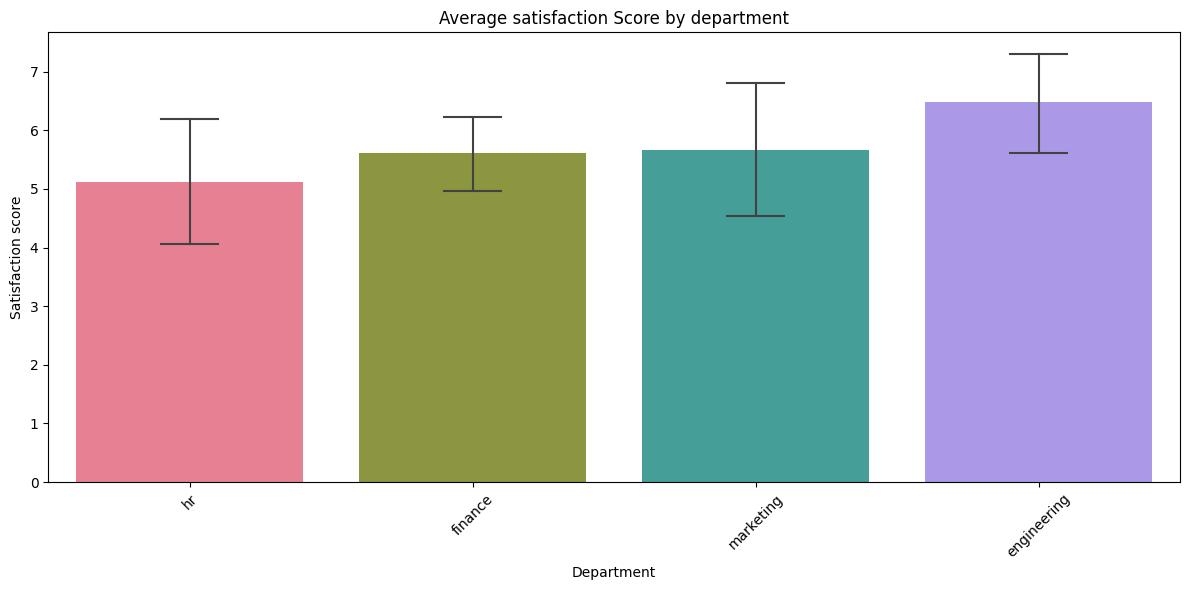

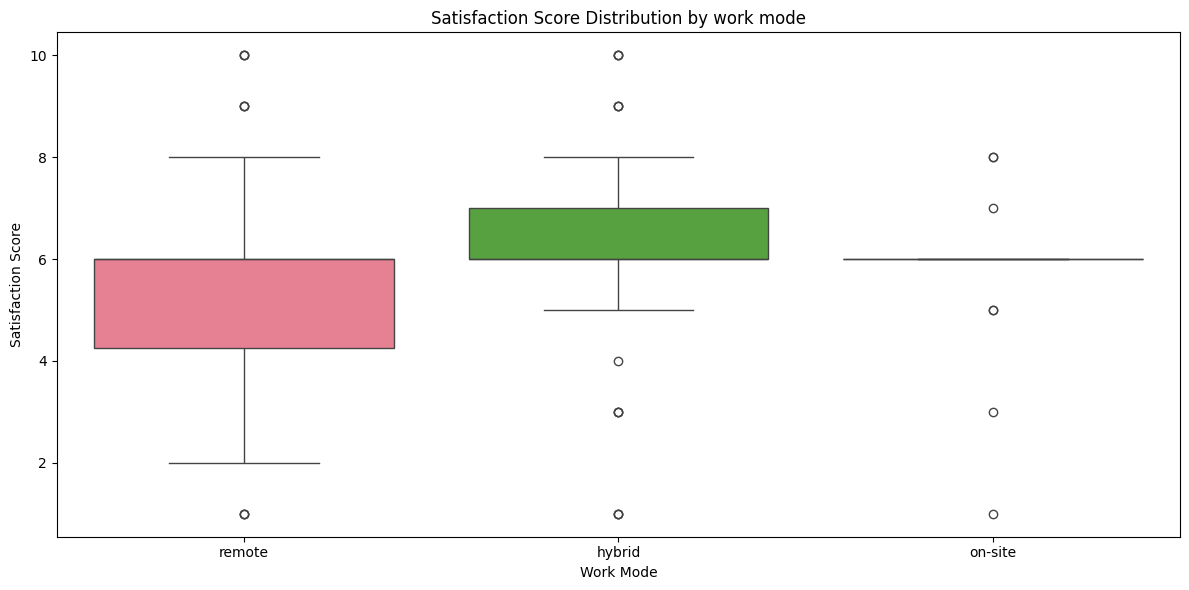

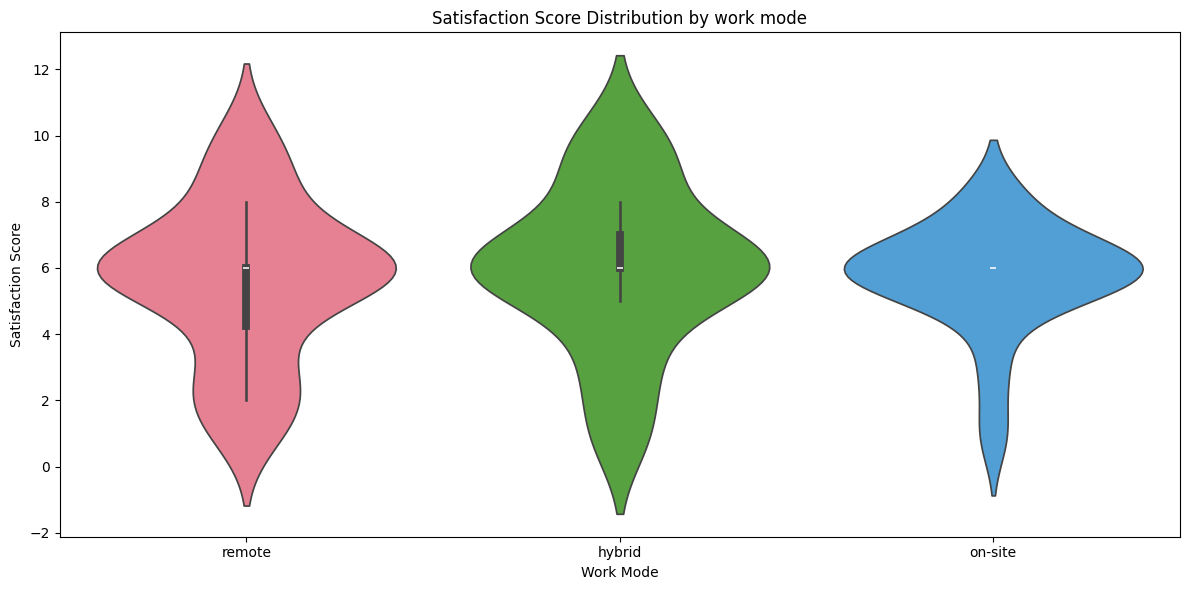


        # Employee Performance Report

        **Generated on:** 2026-06-14

        ## Key Metrics
        - Total Employees: 100
        - Average Satisfaction Score: 5.74

        ## Summary
        - Department with highest satisfaction: engineering
        - Most common work mode: remote
    

In [ ]:
df = clean_data(df)
df = handle_missing_values(df)

display(Markdown(generate_report_markdown(df)))

satisfaction_bar_plt(df)
satisfaction_box_plt(df, plt_type='box')
satisfaction_box_plt(df, plt_type='violin')